# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    put_fig_letter,
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance_groupby,
    compute_variance,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

from diagnosis import synthetic_figure
from cstes import U2, c0

# Generate

In [3]:
dt = 3
distance_to_coast_max = 20e3
alti_product_key = "swot2km"

In [4]:
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot250m",
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)


comb_list = [
    update_dict(base_dic, {"alti_diff_method": "xarray_diff", "ggd_var": "etac"}),
    update_dict(base_dic, {"alti_diff_method": "xarray_diff", "ggd_var": "etaf"}),
    update_dict(base_dic, {"alti_diff_method": "diff_only", "ggd_var": "etac"}),
    update_dict(base_dic, {"alti_diff_method": "diff_only", "ggd_var": "etaf"}),
    base_dic,
    update_dict(base_dic, {"ggd_var": "fromduacsv_unfiltered"}),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "xarray_diff",
            "ggd_var": "etac",
        },
    ),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "xarray_diff",
            "ggd_var": "etaf",
        },
    ),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "diff_only",
            "ggd_var": "etac",
        },
    ),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "diff_only",
            "ggd_var": "etaf",
        },
    ),
    update_dict(base_dic, {"alti_product_key": "swot2km"}),
    update_dict(
        base_dic, {"alti_product_key": "swot2km", "ggd_var": "fromduacsv_unfiltered"}
    ),
    update_dict(base_dic, {"alti_product_key": "L4_noswot_regional"}),
    update_dict(base_dic, {"alti_product_key": "L4_noswot_global"}),
    update_dict(base_dic, {"alti_product_key": "L4_withnadirswot"}),
]

l = [
    "L3-250m-xr-etac",
    "L3-250m-xr-etaf",
    "L3-250m-stencil-etac",
    "L3-250m-stencil-etaf",
    "L3-250m-duacsv",
    "L3-250m-duacsv_unfiltered",
    "L3-2km-xr-etac",
    "L3-2km-xr-etaf",
    "L3-2km-stencil-etac",
    "L3-2km-stencil-etaf",
    "L3-2km-duacsv",
    "L3-2km-duacsv_unfiltered",
    "L4-no-SWOT-regional-duacsv",
    "L4-no-SWOT-global-duacsv",
    "L4-SWOT-nadir-duacsv",
]


ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

# DEPTH 15M
base_dic = dict(
    dt="12h",
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot250m",
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="15",
)
comb_list = [
    update_dict(base_dic, {"alti_diff_method": "xarray_diff", "ggd_var": "etac"}),
    update_dict(base_dic, {"alti_diff_method": "xarray_diff", "ggd_var": "etaf"}),
    update_dict(base_dic, {"alti_diff_method": "diff_only", "ggd_var": "etac"}),
    update_dict(base_dic, {"alti_diff_method": "diff_only", "ggd_var": "etaf"}),
    base_dic,
    update_dict(base_dic, {"ggd_var": "fromduacsv_unfiltered"}),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "xarray_diff",
            "ggd_var": "etac",
        },
    ),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "xarray_diff",
            "ggd_var": "etaf",
        },
    ),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "diff_only",
            "ggd_var": "etac",
        },
    ),
    update_dict(
        base_dic,
        {
            "alti_product_key": "swot2km",
            "alti_diff_method": "diff_only",
            "ggd_var": "etaf",
        },
    ),
    update_dict(base_dic, {"alti_product_key": "swot2km"}),
    update_dict(
        base_dic, {"alti_product_key": "swot2km", "ggd_var": "fromduacsv_unfiltered"}
    ),
    update_dict(base_dic, {"alti_product_key": "L4_noswot_regional"}),
    update_dict(base_dic, {"alti_product_key": "L4_noswot_global"}),
    update_dict(base_dic, {"alti_product_key": "L4_withnadirswot"}),
]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)


KeyboardInterrupt



In [ ]:
ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)

DS.to_netcdf(
    os.path.join(
        zarr_dir, "diag_files", f"alticomp_id_comb_row_number_nospotternomelodi.nc"
    )
)

ds = compute_variance(DS, compute_error="centrallimit") / U2

# Closure figs
df = ds.to_dataframe()
df = (
    df.reset_index()
    .rename(columns={"id_comb": "Altimetric product"})
    .set_index("Altimetric product")
)
ds.to_netcdf(os.path.join(zarr_dir, "diag_files", f"alticomp_nospotternomelodi.nc"))

In [5]:
DS = xr.open_dataset(
    os.path.join(
        zarr_dir, "diag_files", f"alticomp_id_comb_row_number_nospotternomelodi.nc"
    )
)

In [5]:
DS

<xarray.Dataset> Size: 591MB
Dimensions:            (id_comb: 15, row_number: 48455)
Coordinates: (12/13)
    datetime           (id_comb, row_number) datetime64[ns] 6MB ...
    longitude          (id_comb, row_number) float64 6MB ...
    latitude           (id_comb, row_number) float64 6MB ...
    pass_number        (id_comb, row_number) float64 6MB ...
    time_to_swot       (id_comb, row_number) timedelta64[ns] 6MB ...
    cycle_number       (id_comb, row_number) float64 6MB ...
    ...                 ...
    drifter_type       (id_comb, row_number) <U6 17MB ...
    depth              (id_comb, row_number) float64 6MB ...
    phi                (id_comb, row_number) float64 6MB ...
    distance_to_coast  (row_number) float64 388kB ...
  * row_number         (row_number) int64 388kB 55 56 58 ... 377303 377304
  * id_comb            (id_comb) <U26 2kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadi...
Data variables: (12/31)
    sume               (id_comb, row_number) float64 6MB ...
    acce               (id_comb, row_number) float64 6MB ...
    exce_acc           (id_comb, row_number) float64 6MB ...
    core               (id_comb, row_number) float64 6MB ...
    exce_cor           (id_comb, row_number) float64 6MB ...
    ggde               (id_comb, row_number) float64 6MB ...
    ...                 ...
    prodn_acc_ggd      (id_comb, row_number) float64 6MB ...
    prodn_acc_wd       (id_comb, row_number) float64 6MB ...
    prodn_cor_ggd      (id_comb, row_number) float64 6MB ...
    prodn_cor_wd       (id_comb, row_number) float64 6MB ...
    prodn_ggd_wd       (id_comb, row_number) float64 6MB ...
    comb               (id_comb, row_number) <U106 308MB ...

In [6]:
ds = xr.open_dataset(
    os.path.join(zarr_dir, "diag_files", f"alticomp_nospotternomelodi.nc")
)
df = ds.to_dataframe()
df = (
    df.reset_index()
    .rename(columns={"id_comb": "Altimetric product"})
    .set_index("Altimetric product")
)

In [8]:
ds

<xarray.Dataset> Size: 17kB
Dimensions:           (id_comb: 15)
Coordinates:
  * id_comb           (id_comb) <U26 2kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir...
Data variables: (12/132)
    ACCn              (id_comb) float64 120B 1.789 1.789 1.789 ... 1.789 1.789
    CORn              (id_comb) float64 120B 3.333 3.333 3.333 ... 3.333 3.333
    GGDn              (id_comb) float64 120B 618.1 3.11 466.7 ... 0.3576 0.5474
    WDn               (id_comb) float64 120B 0.07872 0.07872 ... 0.07872 0.07872
    Sn                (id_comb) float64 120B 617.9 2.814 466.4 ... 1.49 1.365
    ACCe              (id_comb) float64 120B 1.74 1.74 1.74 ... 1.74 1.74 1.74
    ...                ...
    er__X_acc_wd      (id_comb) float64 120B 0.09758 0.09758 ... 0.09758 0.09758
    er__X_cor_ggd     (id_comb) float64 120B 7.175 0.5063 ... 0.1604 0.1976
    er__X_cor_wd      (id_comb) float64 120B 0.2392 0.2392 ... 0.2392 0.2392
    er__X_ggd_wd      (id_comb) float64 120B 3.861 0.1244 ... 0.03469 0.04482
    er__D_cyclo       (id_comb) float64 120B 6.03 0.4338 5.143 ... 0.1411 0.1741
    er__D_anticyclo   (id_comb) float64 120B 7.191 0.7626 ... 0.5726 0.5896
Attributes:
    error_method:  centrallimit

# Closure figs

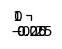

In [9]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0, 1, color=c0["ggd"], label="Balanced signal contribution")
# ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()

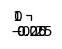

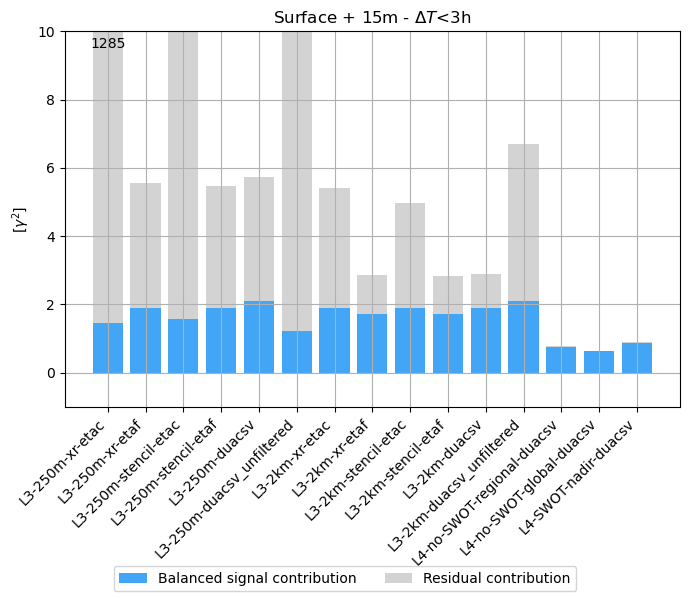

In [10]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0, 1, color=c0["ggd"], label="Balanced signal contribution")
# ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
    ax.bar(i, df_.B_ggd, color=c0["ggd"])

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    # ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    # ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(ticks=np.arange(len(df)), labels=df.index, rotation=45, ha="right")
ax.set_title(rf"Surface + 15m - $\Delta T$<{dt}h")
ax.set_ylim(-1, 10)
ax.annotate(f"{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}", (0, 9.5), ha="center")
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))

In [11]:
DS[["accn", "ggdn", "corn", "wdn"]].mean("row_number") / DS[
    ["accn", "ggdn", "corn", "wdn"]
].std("row_number")

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 15)
Coordinates:
  * id_comb  (id_comb) <U26 2kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 120B -0.06949 -0.06949 ... -0.06949 -0.06949
    ggdn     (id_comb) float64 120B -0.02114 -0.124 -0.02227 ... -0.3789 -0.3138
    corn     (id_comb) float64 120B 0.08629 0.08629 0.08629 ... 0.08629 0.08629
    wdn      (id_comb) float64 120B 0.1551 0.1551 0.1551 ... 0.1551 0.1551

In [12]:
v = ["accn", "ggdn", "corn", "wdn", "acce", "ggde", "core", "wde"]
(DS[v] ** 2).mean("row_number") / DS[v].var("row_number")

<xarray.Dataset> Size: 3kB
Dimensions:  (id_comb: 15)
Coordinates:
  * id_comb  (id_comb) <U26 2kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 120B 1.005 1.005 1.005 ... 1.005 1.005 1.005
    ggdn     (id_comb) float64 120B 1.0 1.015 1.0 1.016 ... 1.106 1.144 1.098
    corn     (id_comb) float64 120B 1.007 1.007 1.007 ... 1.007 1.007 1.007
    wdn      (id_comb) float64 120B 1.024 1.024 1.024 ... 1.024 1.024 1.024
    acce     (id_comb) float64 120B 1.004 1.004 1.004 ... 1.004 1.004 1.004
    ggde     (id_comb) float64 120B 1.0 1.025 1.0 1.026 ... 1.187 1.167 1.149
    core     (id_comb) float64 120B 1.076 1.076 1.076 ... 1.076 1.076 1.076
    wde      (id_comb) float64 120B 1.101 1.101 1.101 ... 1.101 1.101 1.101

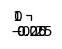

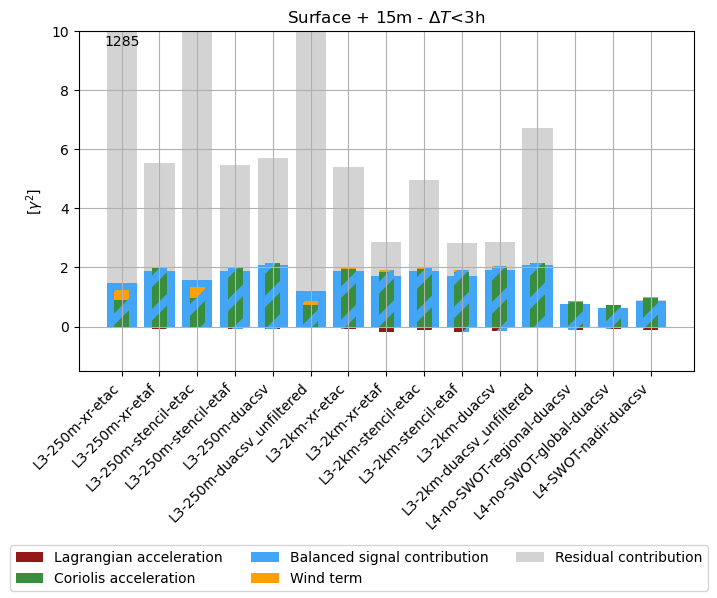

In [13]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
ax.bar(0, 1, color=c0["acc"], label="Lagrangian acceleration")
ax.bar(0, 1, color=c0["cor"], label="Coriolis acceleration")
ax.bar(0, 1, color=c0["ggd"], label="Balanced signal contribution")
ax.bar(0, 1, color=c0["wd"], label="Wind term")
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
    ax.bar(i, df_.B_ggd, color=c0["ggd"])

    plt.rcParams["hatch.color"] = c0["ggd"]
    ax.bar(i, df_.X_acc_ggd / 2, color=c0["acc"], hatch="/", width=0.4, label="")
    ax.bar(i, df_.X_cor_ggd / 2, color=c0["cor"], hatch="/", width=0.4)
    ax.bar(
        i,
        df_.X_ggd_wd / 2,
        color=c0["wd"],
        hatch="/",
        bottom=df_.X_cor_ggd / 2,
        width=0.4,
    )

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(ticks=np.arange(len(df)), labels=df.index, rotation=45, ha="right")
ax.set_title(rf"Surface + 15m - $\Delta T$<{dt}h")
ax.set_ylim(-1.5, 10)
ax.annotate(f"{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}", (0, 9.5), ha="center")
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))

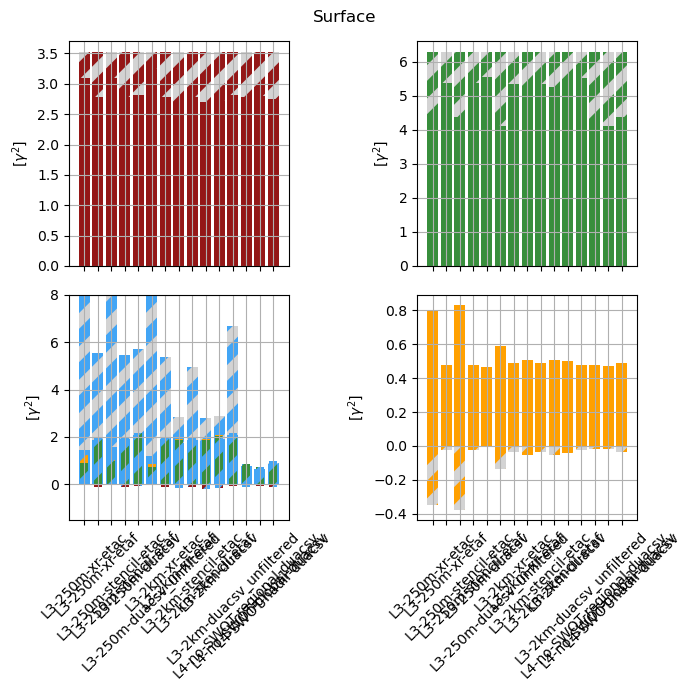

In [14]:
# Alti comparison
vars = ["acc", "cor", "ggd", "wd"]
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize=(7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax = axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_["E_" + vars[j]] > 0:
            ax.bar(
                i,
                df_["E_" + vars[j]],
                bottom=df_["B_" + vars[j]],
                color=c0[vars[j]],
                hatch="/",
            )
        else:
            ax.bar(i, df_["E_" + vars[j]], color=c0[vars[j]], hatch="/")
        ax.bar(i, df_["B_" + vars[j]], color=c0[vars[j]])

    ax = axs[2]
    plt.rcParams["hatch.color"] = c0["ggd"]
    ax.bar(i, df_.X_acc_ggd / 2, color=c0["acc"], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd / 2, color=c0["cor"], hatch="/", width=0.6)
    ax.bar(
        i,
        df_.X_ggd_wd / 2,
        color=c0["wd"],
        hatch="/",
        bottom=df_.X_cor_ggd / 2,
        width=0.6,
    )

for ax in axs:
    ax.grid()
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_xticks(ticks=np.arange(len(df)), labels=df.index, rotation=45)

axs[2].set_ylim(-1.5, 8)
fig.suptitle("Surface")
fig.tight_layout()
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))

# For papers


### Stencil diff

In [15]:
df0 = df.copy()
df0 = df.loc[
    [
        "L3-250m-stencil-etac",
        "L3-250m-stencil-etaf",
        "L3-2km-stencil-etac",
        "L3-2km-stencil-etaf",
        "L4-SWOT-nadir-duacsv",
        "L4-no-SWOT-regional-duacsv",
        "L4-no-SWOT-global-duacsv",
    ]
]
df0 = df0.reset_index()
df0["Altimetric product"] = [
    "Unfiltered L3-250m",
    "Filtered L3-250m",
    "Unfiltered L3-2km",
    "Filtered L3-2km",
    "L4-SWOT-nadir",
    "L4-regional",
    "L4-global",
]
df0 = df0.set_index("Altimetric product")

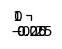

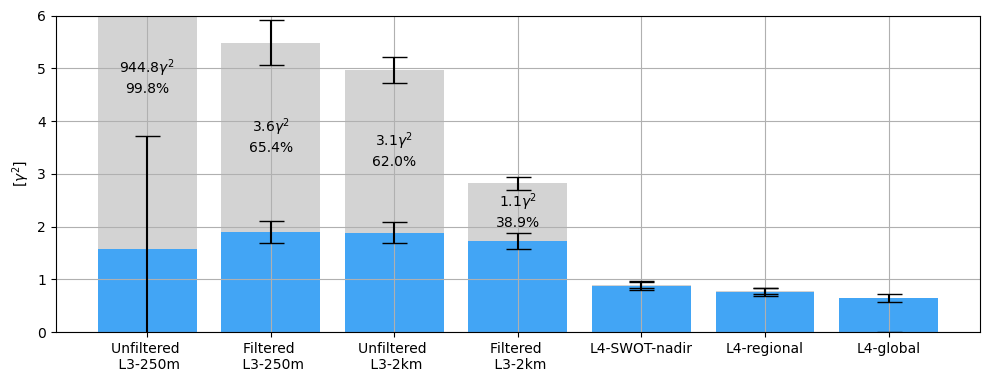

In [16]:
error_kwargs = dict(color="k", capsize=9)

fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0, 1, color=c0["ggd"], label="Balanced contribution")
# ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(10, 4))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df0)):
    df_ = df0.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd + df_.B_ggd, df_.er__E_ggd, **error_kwargs)
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd, df_.er__E_ggd, **error_kwargs)
    ax.bar(i, df_.B_ggd, color=c0["ggd"])
    ax.errorbar(i, df_.B_ggd, df_.er__B_ggd, **error_kwargs)
    if i == 0:
        ax.text(
            i,
            5,
            str(np.round(df_["E_ggd"], 1)) + r"$\gamma^2$",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax.text(
            i,
            4.6,
            str(np.round(df_["E_ggd"] / df_["GGD"] * 100, 1)) + "%",
            horizontalalignment="center",
            verticalalignment="center",
        )
    if i in [1, 2, 3]:
        ax.text(
            i,
            df_["B_ggd"] + df_["E_ggd"] / 2 + 0.2,
            str(np.round(df_["E_ggd"], 1)) + r"$\gamma^2$",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax.text(
            i,
            df_["B_ggd"] + df_["E_ggd"] / 2 - 0.2,
            str(np.round(df_["E_ggd"] / df_["GGD"] * 100, 1)) + "%",
            horizontalalignment="center",
            verticalalignment="center",
        )

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    # ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    # ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(
    ticks=np.arange(len(df0)),
    labels=[
        f.replace("Unfiltered", "Unfiltered \n").replace("Filtered", "Filtered \n")
        for f in df0.index
    ],
    ha="center",
)
# ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0, 6)
# put_fig_letter(fig, ax, 'c')
# ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
# fig.legend(handles, labels, ncol=3, loc="lower center")
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))

### Stencil diff for Unfiltered + duacs velocities for filtered

In [17]:
df0 = df.loc[
    [
        "L3-250m-stencil-etac",
        "L3-250m-duacsv",
        "L3-2km-stencil-etac",
        "L3-2km-duacsv",
        "L4-SWOT-nadir-duacsv",
        "L4-no-SWOT-regional-duacsv",
        "L4-no-SWOT-global-duacsv",
    ]
]
df0 = df0.reset_index()
df0["Altimetric product"] = [
    "Unfiltered L3-250m",
    "Filtered L3-250m",
    "Unfiltered L3-2km",
    "Filtered L3-2km",
    "L4-SWOT-nadir",
    "L4-regional",
    "L4-global",
]
df0 = df0.set_index("Altimetric product")

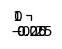

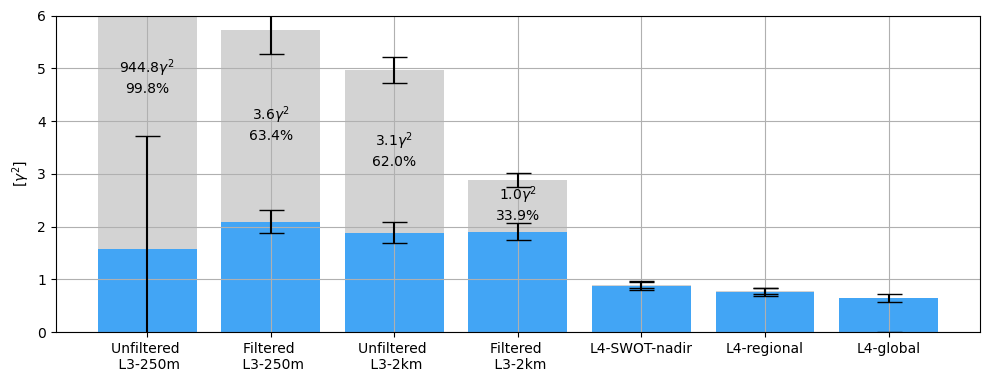

In [18]:
error_kwargs = dict(color="k", capsize=9)

fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0, 1, color=c0["ggd"], label="Balanced contribution")
# ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(10, 4))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df0)):
    df_ = df0.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd + df_.B_ggd, df_.er__E_ggd, **error_kwargs)
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd, df_.er__E_ggd, **error_kwargs)
    ax.bar(i, df_.B_ggd, color=c0["ggd"])
    ax.errorbar(i, df_.B_ggd, df_.er__B_ggd, **error_kwargs)
    if i == 0:
        ax.text(
            i,
            5,
            str(np.round(df_["E_ggd"], 1)) + r"$\gamma^2$",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax.text(
            i,
            4.6,
            str(np.round(df_["E_ggd"] / df_["GGD"] * 100, 1)) + "%",
            horizontalalignment="center",
            verticalalignment="center",
        )
    if i in [1, 2, 3]:
        ax.text(
            i,
            df_["B_ggd"] + df_["E_ggd"] / 2 + 0.2,
            str(np.round(df_["E_ggd"], 1)) + r"$\gamma^2$",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax.text(
            i,
            df_["B_ggd"] + df_["E_ggd"] / 2 - 0.2,
            str(np.round(df_["E_ggd"] / df_["GGD"] * 100, 1)) + "%",
            horizontalalignment="center",
            verticalalignment="center",
        )

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    # ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    # ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(
    ticks=np.arange(len(df0)),
    labels=[
        f.replace("Unfiltered", "Unfiltered \n").replace("Filtered", "Filtered \n")
        for f in df0.index
    ],
    ha="center",
)
# ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0, 6)
# ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
# fig.legend(handles, labels, ncol=3, loc="lower center")
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))

### Selection for PhD defence

In [15]:
df0 = df.loc[
    [
        "L3-250m-stencil-etac",
        "L3-250m-stencil-etaf",
        "L3-2km-stencil-etac",
        "L3-2km-stencil-etaf",
        "L4-SWOT-nadir-duacsv",
    ]
]
df0 = df0.reset_index()
df0["Altimetric product"] = [
    "SWOT - Calibré 250m",
    "SWOT - Filtré 2km",
    "SWOT - Calibré 250m",
    "SWOT - Filtré 2km",
    "Grillé avant SWOT",
]
df0 = df0.set_index("Altimetric product")

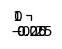

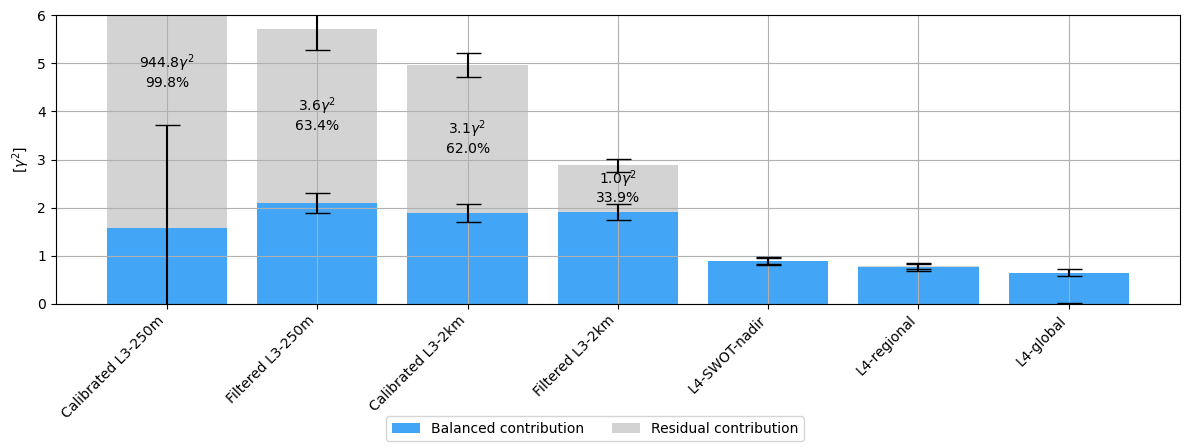

In [24]:
error_kwargs = dict(color="k", capsize=9)

fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0, 1, color=c0["ggd"], label="Balanced contribution")
# ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(12, 4.5))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df0)):
    df_ = df0.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd + df_.B_ggd, df_.er__E_ggd, **error_kwargs)
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd, df_.er__E_ggd, **error_kwargs)
    ax.bar(i, df_.B_ggd, color=c0["ggd"])
    ax.errorbar(i, df_.B_ggd, df_.er__B_ggd, **error_kwargs)
    if i == 0:
        ax.text(
            i,
            5,
            str(np.round(df_["E_ggd"], 1)) + r"$\gamma^2$",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax.text(
            i,
            4.6,
            str(np.round(df_["E_ggd"] / df_["GGD"] * 100, 1)) + "%",
            horizontalalignment="center",
            verticalalignment="center",
        )
    if i in [1, 2, 3]:
        ax.text(
            i,
            df_["B_ggd"] + df_["E_ggd"] / 2 + 0.2,
            str(np.round(df_["E_ggd"], 1)) + r"$\gamma^2$",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax.text(
            i,
            df_["B_ggd"] + df_["E_ggd"] / 2 - 0.2,
            str(np.round(df_["E_ggd"] / df_["GGD"] * 100, 1)) + "%",
            horizontalalignment="center",
            verticalalignment="center",
        )

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    # ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    # ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(ticks=np.arange(len(df0)), labels=df0.index, rotation=45, ha="right")
# ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0, 6)
# ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))

In [25]:
df0["E_ggd"]

Altimetric product
Calibrated L3-250m    944.848675
Filtered L3-250m        3.628372
Calibrated L3-2km       3.081023
Filtered L3-2km         0.976380
L4-SWOT-nadir           0.004035
L4-regional             0.018225
L4-global              -0.047301
Name: E_ggd, dtype: float64

In [26]:
df0["E_ggd"]

Altimetric product
Calibrated L3-250m    944.848675
Filtered L3-250m        3.628372
Calibrated L3-2km       3.081023
Filtered L3-2km         0.976380
L4-SWOT-nadir           0.004035
L4-regional             0.018225
L4-global              -0.047301
Name: E_ggd, dtype: float64

In [27]:
df0.E_ggd, df0.er__E_ggd

(Altimetric product
 Calibrated L3-250m    944.848675
 Filtered L3-250m        3.628372
 Calibrated L3-2km       3.081023
 Filtered L3-2km         0.976380
 L4-SWOT-nadir           0.004035
 L4-regional             0.018225
 L4-global              -0.047301
 Name: E_ggd, dtype: float64,
 Altimetric product
 Calibrated L3-250m    105.429214
 Filtered L3-250m        0.444029
 Calibrated L3-2km       0.243889
 Filtered L3-2km         0.131427
 L4-SWOT-nadir           0.055897
 L4-regional             0.054518
 L4-global               0.049141
 Name: er__E_ggd, dtype: float64)

In [31]:
df0.B_ggd.loc["Unfiltered L3-2km"] - df0.B_ggd.loc["Filtered L3-2km"], np.sqrt(
    df0.er__B_ggd.loc["Unfiltered L3-2km"] ** 2
    + df0.er__B_ggd.loc["Filtered L3-2km"] ** 2
),

(-0.017191585075381433, 0.2516489210565507)

In [32]:
df0.E_ggd.loc["Filtered L3-250m"] - df0.E_ggd.loc["Filtered L3-2km"], np.sqrt(
    df0.er__E_ggd.loc["Filtered L3-250m"] ** 2
    + df0.er__E_ggd.loc["Filtered L3-2km"] ** 2
),

(2.6519924093254468, 0.46307076603778297)

In [33]:
df0.B_ggd.loc["Filtered L3-250m"] - df0.B_ggd.loc["Filtered L3-2km"], np.sqrt(
    df0.er__B_ggd.loc["Filtered L3-250m"] ** 2
    + df0.er__B_ggd.loc["Filtered L3-2km"] ** 2
),

(0.19022127594457094, 0.2668676558852113)

In [34]:
df0.B_ggd, df0.er__B_ggd

(Altimetric product
 Calibrated L3-250m    1.568308
 Filtered L3-250m      2.092753
 Calibrated L3-2km     1.885341
 Filtered L3-2km       1.902532
 L4-SWOT-nadir         0.879994
 L4-regional           0.757637
 L4-global             0.643186
 Name: B_ggd, dtype: float64,
 Altimetric product
 Calibrated L3-250m    2.140078
 Filtered L3-250m      0.212819
 Calibrated L3-2km     0.193393
 Filtered L3-2km       0.161017
 L4-SWOT-nadir         0.085950
 L4-regional           0.078439
 L4-global             0.069487
 Name: er__B_ggd, dtype: float64)

In [37]:
df0.E_ggd / df0.GGD * 100, df0.E_ggd / df0.GGD * 100 * np.sqrt(
    (df0.er__E_ggd / df0.E_ggd) ** 2 + (df0.er__GGD / df0.GGD) ** 2
)

(Altimetric product
 Calibrated L3-250m    99.834290
 Filtered L3-250m      65.423444
 Calibrated L3-2km     62.037805
 Filtered L3-2km       38.853873
 L4-SWOT-nadir          0.456440
 L4-regional            2.348966
 L4-global             -7.937984
 dtype: float64,
 Altimetric product
 Calibrated L3-250m    15.744911
 Filtered L3-250m       9.581364
 Calibrated L3-2km      6.221462
 Filtered L3-2km        5.167794
 L4-SWOT-nadir          6.323092
 L4-regional            7.028555
 L4-global             -8.265098
 dtype: float64)

In [37]:
df0.B_ggd / df0.B_ggd.loc["Filtered L3-2km"] * 100, df0.B_ggd / df0.B_ggd.loc[
    "Filtered L3-2km"
] * 100 * np.sqrt(
    (
        (df0.er__B_ggd / df0.B_ggd) ** 2
        + (df0.er__B_ggd.loc["Filtered L3-2km"] / df0.B_ggd.loc["Filtered L3-2km"]) ** 2
    )
)

(Altimetric product
 Calibrated L3-250m     82.432680
 Filtered L3-250m      109.998322
 Calibrated L3-2km      99.096384
 Filtered L3-2km       100.000000
 L4-SWOT-nadir          46.253829
 L4-regional            39.822546
 L4-global              33.806830
 Name: B_ggd, dtype: float64,
 Altimetric product
 Calibrated L3-250m    112.701904
 Filtered L3-250m       14.553181
 Calibrated L3-2km      13.178251
 Filtered L3-2km        11.968909
 L4-SWOT-nadir           5.977735
 L4-regional             5.325125
 L4-global               4.639614
 dtype: float64)

In [38]:
df0.B_ggd / df0.B_ggd.loc["Filtered L3-2km"]

Altimetric product
Calibrated L3-250m    0.824327
Filtered L3-250m      1.099983
Calibrated L3-2km     0.990964
Filtered L3-2km       1.000000
L4-SWOT-nadir         0.462538
L4-regional           0.398225
L4-global             0.338068
Name: B_ggd, dtype: float64

In [70]:
def sshnoisestd_from_MSnoiseggd(E_ggd, er__E_ggd, d=2e3):
    """
    E_ggd : pressure gradient MS in gamma^2
    d : grid spacing in m
    """
    print("Caution : E_ggd must be given in gamma^2, std is return in mm")
    g = 9.81
    d = 2e3
    cste = 4 * g**2 / (840 * d) ** 2
    S2 = (3**2) + (32**2) + (168**2) + (672**2)
    return (
        np.sqrt(E_ggd * U2 / cste / S2) * 1e3,
        np.sqrt(E_ggd * U2 / cste / S2) * (er__E_ggd / E_ggd) / 2 * 1e3,
    )

# Related SSH RMS 

In [71]:
# from diagnosis import sshnoisestd_from_MSnoiseggd
a, b = sshnoisestd_from_MSnoiseggd(df0.E_ggd, df0.er__E_ggd)
print(a, b)  # cm

Caution : E_ggd must be given in gamma^2, std is return in mm
Altimetric product
Calibrated L3-250m    37.235713
Filtered L3-250m       2.294237
Calibrated L3-2km      2.126307
Filtered L3-2km        1.267446
L4-SWOT-nadir          0.076949
L4-regional            0.163534
L4-global                   NaN
Name: E_ggd, dtype: float64 Altimetric product
Calibrated L3-250m    2.077440
Filtered L3-250m      0.135402
Calibrated L3-2km     0.084158
Filtered L3-2km       0.073614
L4-SWOT-nadir         0.532984
L4-regional           0.244599
L4-global                  NaN
dtype: float64


In [72]:
df.E_ggd / df.GGD * 100

Altimetric product
L3-250m-xr-etac               99.886035
L3-250m-xr-etaf               65.834240
L3-250m-stencil-etac          99.834290
L3-250m-stencil-etaf          65.423444
L3-250m-duacsv                63.420601
L3-250m-duacsv_unfiltered     99.954940
L3-2km-xr-etac                64.889211
L3-2km-xr-etaf                39.350979
L3-2km-stencil-etac           62.037805
L3-2km-stencil-etaf           38.853873
L3-2km-duacsv                 33.914891
L3-2km-duacsv_unfiltered      68.696716
L4-no-SWOT-regional-duacsv     2.348966
L4-no-SWOT-global-duacsv      -7.937984
L4-SWOT-nadir-duacsv           0.456440
dtype: float64

# Differenciation methods comparisons

In [43]:
error_kwargs = dict(color="k", capsize=9)

In [44]:
df1 = df.copy()
df1 = df1.loc[["L3-250m-duacsv", "L3-250m-stencil-etaf", "L3-250m-xr-etaf"]]
df1 = df1.reset_index()
df1["Altimetric product"] = [
    "From duacs velocities",
    "Stencil differentiation",
    "Centered differentiation",
]
df1 = df1.set_index("Altimetric product")

df2 = df.copy()
df2 = df2.loc[["L3-2km-duacsv", "L3-2km-stencil-etaf", "L3-2km-xr-etaf"]]
df2 = df2.reset_index()
df2["Altimetric product"] = [
    "From duacs velocities",
    "Stencil differentiation",
    "Centered differentiation",
]
df2 = df2.set_index("Altimetric product")

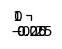

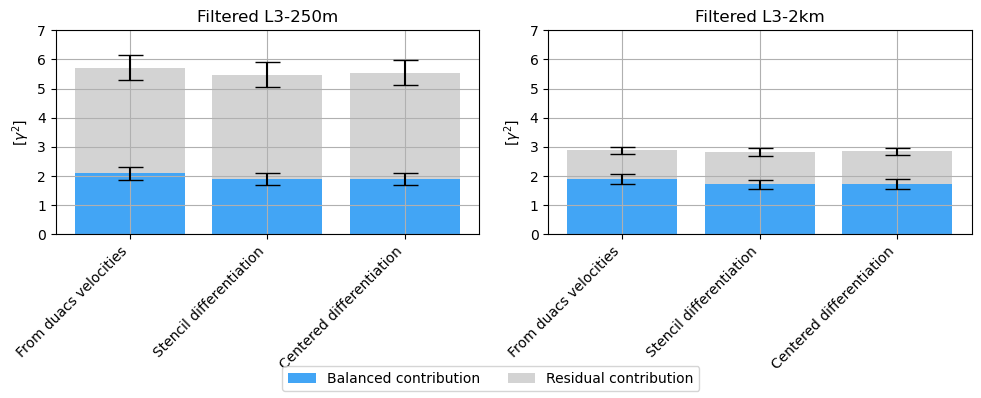

In [45]:
fig, ax = plt.subplots(figsize=(1e-3, 1e-3))
# ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
# ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0, 1, color=c0["ggd"], label="Balanced contribution")
# ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0, 1, color="lightgrey", label="Residual contribution")

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, axs = plt.subplots(1, 2, frameon=False, figsize=(10, 4))
plt.rcParams["axes.edgecolor"] = "k"

ax = axs[0]
for i in range(len(df1)):
    df_ = df1.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd + df_.B_ggd, df_.er__E_ggd, **error_kwargs)
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd, df_.er__E_ggd, **error_kwargs)
    ax.bar(i, df_.B_ggd, color=c0["ggd"])
    ax.errorbar(i, df_.B_ggd, df_.er__B_ggd, **error_kwargs)

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    # ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    # ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(ticks=np.arange(len(df1)), labels=df1.index, rotation=45, ha="right")
# ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0, 7)
ax.set_title("Filtered L3-250m")

ax = axs[1]
for i in range(len(df2)):
    df_ = df2.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd > 0:
        ax.bar(i, df_.E_ggd, bottom=df_.B_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd + df_.B_ggd, df_.er__E_ggd, **error_kwargs)
    else:
        ax.bar(i, df_.E_ggd, color="lightgrey")
        ax.errorbar(i, df_.E_ggd, df_.er__E_ggd, **error_kwargs)
    ax.bar(i, df_.B_ggd, color=c0["ggd"])
    ax.errorbar(i, df_.B_ggd, df_.er__B_ggd, **error_kwargs)

    # plt.rcParams["hatch.color"] = c0['ggd']
    # ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    # ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    # ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)

ax.grid()
ax.set_ylabel(r"[$\gamma^2$]")
ax.set_xticks(ticks=np.arange(len(df2)), labels=df2.index, rotation=45, ha="right")
# ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0, 7)
ax.set_title("Filtered L3-2km")


# ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
# fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))

In [46]:
df2["B_ggd"] / df2["B_ggd"].loc["From duacs velocities"]

Altimetric product
From duacs velocities       1.000000
Stencil differentiation     0.905533
Centered differentiation    0.908144
Name: B_ggd, dtype: float64

In [47]:
df2["E_ggd"] / df2["E_ggd"].loc["From duacs velocities"]

Altimetric product
From duacs velocities       1.000000
Stencil differentiation     1.121199
Centered differentiation    1.148153
Name: E_ggd, dtype: float64

_________
# Velocities errors

In [42]:
DS = xr.open_dataset(
    os.path.join(
        zarr_dir, "diag_files", f"alticomp_id_comb_row_number_nospotternomelodi.nc"
    )
)

# normalisation by f
fc = 2 * 2 * np.pi / 86164.1 * np.sin(DS.latitude * np.pi / 180)
for v in [v for v in DS if "prod" in v]:
    DS[v] = DS[v] / fc
DS = DS.set_coords("comb")
DS = DS / fc

ds = compute_variance(DS, compute_error="centrallimit")
# Closure figs
df = ds.to_dataframe()
df = (
    df.reset_index()
    .rename(columns={"id_comb": "Altimetric product"})
    .set_index("Altimetric product")
)

1505


In [43]:
df0 = df.copy()
df0 = df0.loc[
    [
        "L3-250m-stencil-etac",
        "L3-250m-stencil-etaf",
        "L3-2km-stencil-etac",
        "L3-2km-stencil-etaf",
        "L4-SWOT-nadir-duacsv",
        "L4-no-SWOT-regional-duacsv",
        "L4-no-SWOT-global-duacsv",
    ]
]
df0 = df0.reset_index()
df0["Altimetric product"] = [
    "Unfiltered L3-250m",
    "Filtered L3-250m",
    "Unfiltered L3-2km",
    "Filtered L3-2km",
    "L4-SWOT-nadir",
    "L4-regional",
    "L4-global",
]
df0 = df0.set_index("Altimetric product")

## Velocity error

In [48]:
np.sqrt(df0["Ee_ggd"]), np.sqrt(df0["Ee_ggd"]) / 2 * (df0["er__Ee_ggd"] / df0["Ee_ggd"])

(Altimetric product
 Calibrated L3-250m    2.268399
 Filtered L3-250m      0.135425
 Calibrated L3-2km     0.130661
 Filtered L3-2km       0.080352
 L4-SWOT-nadir         0.031514
 L4-regional           0.032627
 L4-global             0.028094
 Name: Ee_ggd, dtype: float64,
 Altimetric product
 Calibrated L3-250m    0.158788
 Filtered L3-250m      0.007630
 Calibrated L3-2km     0.006562
 Filtered L3-2km       0.005489
 L4-SWOT-nadir         0.005544
 L4-regional           0.005153
 L4-global             0.005486
 dtype: float64)

In [49]:
np.sqrt(df0["E_ggd"] / 2), np.sqrt(df0["E_ggd"] / 2) / 2 * (
    df0["er__E_ggd"] / df0["E_ggd"]
)

(Altimetric product
 Calibrated L3-250m    2.252552
 Filtered L3-250m      0.139411
 Calibrated L3-2km     0.128983
 Filtered L3-2km       0.076899
 L4-SWOT-nadir         0.003229
 L4-regional           0.009350
 L4-global                  NaN
 Name: E_ggd, dtype: float64,
 Altimetric product
 Calibrated L3-250m    0.124874
 Filtered L3-250m      0.008445
 Calibrated L3-2km     0.005139
 Filtered L3-2km       0.004488
 L4-SWOT-nadir         0.046362
 L4-regional           0.015665
 L4-global                  NaN
 dtype: float64)

In [50]:
np.sqrt(df0["En_ggd"]), np.sqrt(df0["En_ggd"]) / 2 * (df0["er__En_ggd"] / df0["En_ggd"])

(Altimetric product
 Calibrated L3-250m    2.236593
 Filtered L3-250m      0.143286
 Calibrated L3-2km     0.127284
 Filtered L3-2km       0.073283
 L4-SWOT-nadir              NaN
 L4-regional                NaN
 L4-global                  NaN
 Name: En_ggd, dtype: float64,
 Altimetric product
 Calibrated L3-250m    0.162992
 Filtered L3-250m      0.013622
 Calibrated L3-2km     0.007753
 Filtered L3-2km       0.007303
 L4-SWOT-nadir              NaN
 L4-regional                NaN
 L4-global                  NaN
 dtype: float64)

In [53]:
np.sqrt(df0["E_cor"])

Altimetric product
Calibrated L3-250m    0.143647
Filtered L3-250m      0.100864
Calibrated L3-2km     0.101302
Filtered L3-2km       0.106833
L4-SWOT-nadir         0.144448
L4-regional           0.149171
L4-global             0.153682
Name: E_cor, dtype: float64

In [67]:
def whitenoise_sigmaSSH_from_E_GGD(E_ggd):
    g = 9.81
    dj = 2e3
    cste = 4 * g**2 / (840 * d) ** 2
    S2 = 3**2 + 32**2 + 168**2 + 672**2
    return E_ggd * U2 / cste / S2